# Módulo de Pré-processamento via Mapa Semântico — MMH

**Objetivo da entrega:** um módulo de pré-processamento de descrições de materiais
hospitalares (base **MMH**, e-Fisco / SEFAZ-PE) **guiado por um mapa semântico** de domínio.

O notebook narra o módulo do texto bruto até o **documento virtual expandido**, que é a saída
que alimenta o casamento CATMAT downstream:

1. **Fontes** — o corpus MMH
2. **Pré-processamento textual** — limpeza, normalização e canonização
3. **Mapa semântico** — o grafo léxico de domínio que guia a expansão
4. **Módulo integrado** — texto bruto → documento virtual expandido
5. **Métricas** — cobertura, OOV e validação downstream

> Usa as funções reais de `preprocessamento_mmh.py` e `rede_semantica_mmh.py`.
> Nenhuma métrica é recalculada à mão: os números vêm de `stats_pipeline.json`.

## 0. Ambiente e fontes

Carregamos o corpus MMH (pares e-Fisco ↔ CATMAT, separador `|`) usando o próprio
`carregar_dados` do módulo — mesma ingestão do pipeline de produção.

In [1]:
import sys, json
from pathlib import Path
from collections import Counter
import pandas as pd

# Localiza a pasta MMH (funciona rodando dentro dela ou de qualquer lugar)
MMH_DIR = Path.cwd()
if not (MMH_DIR / "preprocessamento_mmh.py").exists():
    MMH_DIR = Path("C:/Users/Educação/Downloads/MMH")
sys.path.insert(0, str(MMH_DIR))

from preprocessamento_mmh import (
    carregar_dados, remover_boilerplate, aplicar_sinonimos,
    normalizar_texto, tokenizar, remover_stopwords,
    preprocessar_texto_efisco, extrair_atributos_catmat,
)

df = carregar_dados("principal")
print(f"Corpus MMH carregado: {len(df)} pares e-Fisco <-> CATMAT")
df[["item_efisco", "item_catmat"]].head(3)

INFO | Carregado: 20260408_ground_truth_mmh_limpa.csv  (1264 registros)


Corpus MMH carregado: 1264 pares e-Fisco <-> CATMAT


,item_efisco,item_catmat
0,"AGULHA DE MIELOGRAMA - ACO INOXIDAVEL, (ASPIRA...","AGULHA PUNÇÃO ÓSSEA, MODELO: P/ INFUSÃO , APLI..."
1,"AGULHA DE MIELOGRAMA - ACO INOXIDAVEL, (ASPIRA...","AGULHA PUNÇÃO ÓSSEA, MODELO: P/ INFUSÃO , APLI..."
2,"AGULHA DE MIELOGRAMA - ACO INOXIDAVEL, (ASPIRA...","AGULHA PUNÇÃO ÓSSEA, MODELO: P/ ASPIRAÇÃO, BIÓ..."


In [2]:
stats = json.loads((MMH_DIR / "stats_pipeline.json").read_text(encoding="utf-8"))
f0 = stats["fase0"]
pd.DataFrame({
    "métrica": ["pares totais", "e-Fisco únicos", "CATMAT únicos",
                "classes e-Fisco", "classes CATMAT"],
    "valor":   [f0["n_total"], f0["n_efisco_unicos"], f0["n_catmat_unicos"],
                f0["n_classes_efisco"], f0["n_classes_catmat"]],
})

,métrica,valor
0,pares totais,1264
1,e-Fisco únicos,1012
2,CATMAT únicos,1054
3,classes e-Fisco,19
4,classes CATMAT,30


## 1. Pré-processamento textual

O texto e-Fisco é ruidoso: vem carregado de **boilerplate jurídico** ("O PRODUTO DEVERÁ
ESTAR DE ACORDO COM O ART..."), abreviações e variação de caixa/acentuação. O módulo aplica,
em sequência:

`remover_boilerplate → aplicar_sinonimos → normalizar_texto → tokenizar → remover_stopwords`

Abaixo, cada etapa sobre um item real do corpus.

In [3]:
# Item e-Fisco representativo (com boilerplate e abreviações)
candidatos = df[df["item_efisco"].str.contains("AGULHA", case=False, na=False)]
exemplo = candidatos.iloc[0]["item_efisco"] if len(candidatos) else df.iloc[0]["item_efisco"]

print("BRUTO         :", exemplo[:170])
p1 = remover_boilerplate(exemplo);              print("s/ boilerplate:", p1[:170])
p2 = aplicar_sinonimos(p1);                     print("sinônimos     :", p2[:170])
p3 = normalizar_texto(p2, manter_maiusculas=True); print("normalizado   :", p3[:170])
toks = remover_stopwords(tokenizar(p3));        print("tokens        :", toks)

print("\nSaída do módulo — preprocessar_texto_efisco():")
print("  ", preprocessar_texto_efisco(exemplo))

BRUTO         : AGULHA DE MIELOGRAMA - ACO INOXIDAVEL, (ASPIRATIVA - ESTERNO E CRISTA ILIACA),COM LIMITADOR DE PROFUNDIDADE, SILICONIZADA,,USO UNICO, DESCARTAVEL E ESTERIL,PARA BIOPSIA O
s/ boilerplate: AGULHA DE MIELOGRAMA - ACO INOXIDAVEL, (ASPIRATIVA - ESTERNO E CRISTA ILIACA),COM LIMITADOR DE PROFUNDIDADE, SILICONIZADA,,USO UNICO, DESCARTAVEL E ESTERIL,PARA BIOPSIA O
sinônimos     : AGULHA DE MIELOGRAMA - ACO INOXIDAVEL, (ASPIRATIVA - ESTERNO E CRISTA ILIACA),COM LIMITADOR DE PROFUNDIDADE, SILICONIZADA,,USO UNICO, DESCARTAVEL E ESTERIL,PARA BIOPSIA O
normalizado   : AGULHA DE MIELOGRAMA - ACO INOXIDAVEL, (ASPIRATIVA - ESTERNO E CRISTA ILIACA),COM LIMITADOR DE PROFUNDIDADE, SILICONIZADA,,USO UNICO, DESCARTAVEL E ESTERIL,PARA BIOPSIA O
tokens        : ['AGULHA', 'MIELOGRAMA', 'ACO', 'INOXIDAVEL', 'ASPIRATIVA', 'ESTERNO', 'CRISTA', 'ILIACA', 'LIMITADOR', 'PROFUNDIDADE', 'SILICONIZADA', 'USO', 'UNICO', 'DESCARTAVEL', 'ESTERIL', 'BIOPSIA', 'OSSEA', 'MIELOGRAMA', '15G', 'X', '10', 'CM', 

In [4]:
# Antes -> depois em lote (amostra)
amostra = df.head(6).copy()
amostra["efisco_limpo"] = amostra["item_efisco"].apply(preprocessar_texto_efisco)
amostra[["item_efisco", "efisco_limpo"]]

,item_efisco,efisco_limpo
0,"AGULHA DE MIELOGRAMA - ACO INOXIDAVEL, (ASPIRA...",AGULHA MIELOGRAMA ACO INOXIDAVEL ASPIRATIVA ES...
1,"AGULHA DE MIELOGRAMA - ACO INOXIDAVEL, (ASPIRA...",AGULHA MIELOGRAMA ACO INOXIDAVEL ASPIRATIVA ES...
2,"AGULHA DE MIELOGRAMA - ACO INOXIDAVEL, (ASPIRA...",AGULHA MIELOGRAMA ACO INOXIDAVEL ASPIRATIVA ES...
3,"AGULHA DE MIELOGRAMA - ACO INOXIDAVEL, (ASPIRA...",AGULHA MIELOGRAMA ACO INOXIDAVEL ASPIRATIVA ES...
4,"AGULHA DE MIELOGRAMA - ILLINOIS, 18 GA, DESCAR...",AGULHA MIELOGRAMA ILLINOIS 18G DESCARTAVEL BIO...
5,AGULHA PARA PUNCAO DESCARTAVEL - EM MATERIAL A...,AGULHA PUNCAO DESCARTAVEL MATERIAL ATOXICO API...


## 2. Mapa semântico

O mapa é um **grafo léxico de domínio** (`networkx.MultiDiGraph`) com 5 tipos de nó
— `PDM`, `Conceito`, `Termo`, `ValorDeAtributo`, `Unidade` — construído a partir de três fontes:

- **(a) verteba estrutural** — rótulos CATMAT/PDM extraídos de `item_catmat`;
- **(b) jargão do histórico** — abreviações e associações mineradas por **NPMI** dos pares vinculados;
- **(c) semente lexical curada** — abreviações, variantes ortográficas e hierarquias do domínio de compras.

É esse grafo que transforma o pré-processamento de "limpeza de string" em **normalização semântica**.

In [5]:
from rede_semantica_mmh import (
    construir_grafo, visualizar_grafo,
    normalizar_termo, expandir_por_ativacao, ancorar_pdm,
)

G = construir_grafo("principal")
nos_por_tipo    = Counter(d["tipo"]   for _, d    in G.nodes(data=True))
arestas_por_rel = Counter(d["relacao"] for _, _, d in G.edges(data=True))

print(f"Mapa semântico: {G.number_of_nodes()} nós | {G.number_of_edges()} arestas\n")
print("Nós por tipo:")
for t, c in sorted(nos_por_tipo.items(), key=lambda x: -x[1]):
    print(f"  {t:16s} {c:6d}")
print("\nArestas por relação:")
for r, c in sorted(arestas_por_rel.items(), key=lambda x: -x[1]):
    print(f"  {r:20s} {c:6d}")

INFO | Carregado: 20260408_ground_truth_mmh_limpa.csv  (1264 registros)


INFO | (a) Construindo verteba estrutural a partir de 1264 registros CATMAT...


INFO |   -> 191 nos PDM criados


INFO |   -> 1078 nos Conceito criados


INFO | (b) Minerando jargao do historico de vinculos...


...

INFO |   Arestas mapeiaParaPDM: 2173


INFO |   Arestas relacionadoA: 44774


INFO |   Arestas sinonimoDe: 10


INFO |   Arestas varianteOrtograficaDe: 7


Mapa semântico: 4198 nós | 47084 arestas

Nós por tipo:
  Conceito           1756
  Termo              1675
  ValorDeAtributo     560
  PDM                 191
  Unidade              16

Arestas por relação:
  relacionadoA          44774
  mapeiaParaPDM          2173
  abreviacaoDe             68
  formaCanonicaDe          27
  convertePara             14
  hiperonimoDe             11
  sinonimoDe               10
  varianteOrtograficaDe      7


PDM em foco: FIO DE SUTURA AGULHADO


INFO | Visualizacao salva em: C:\Users\Educação\Downloads\MMH\vizinhanca_apresentacao.png


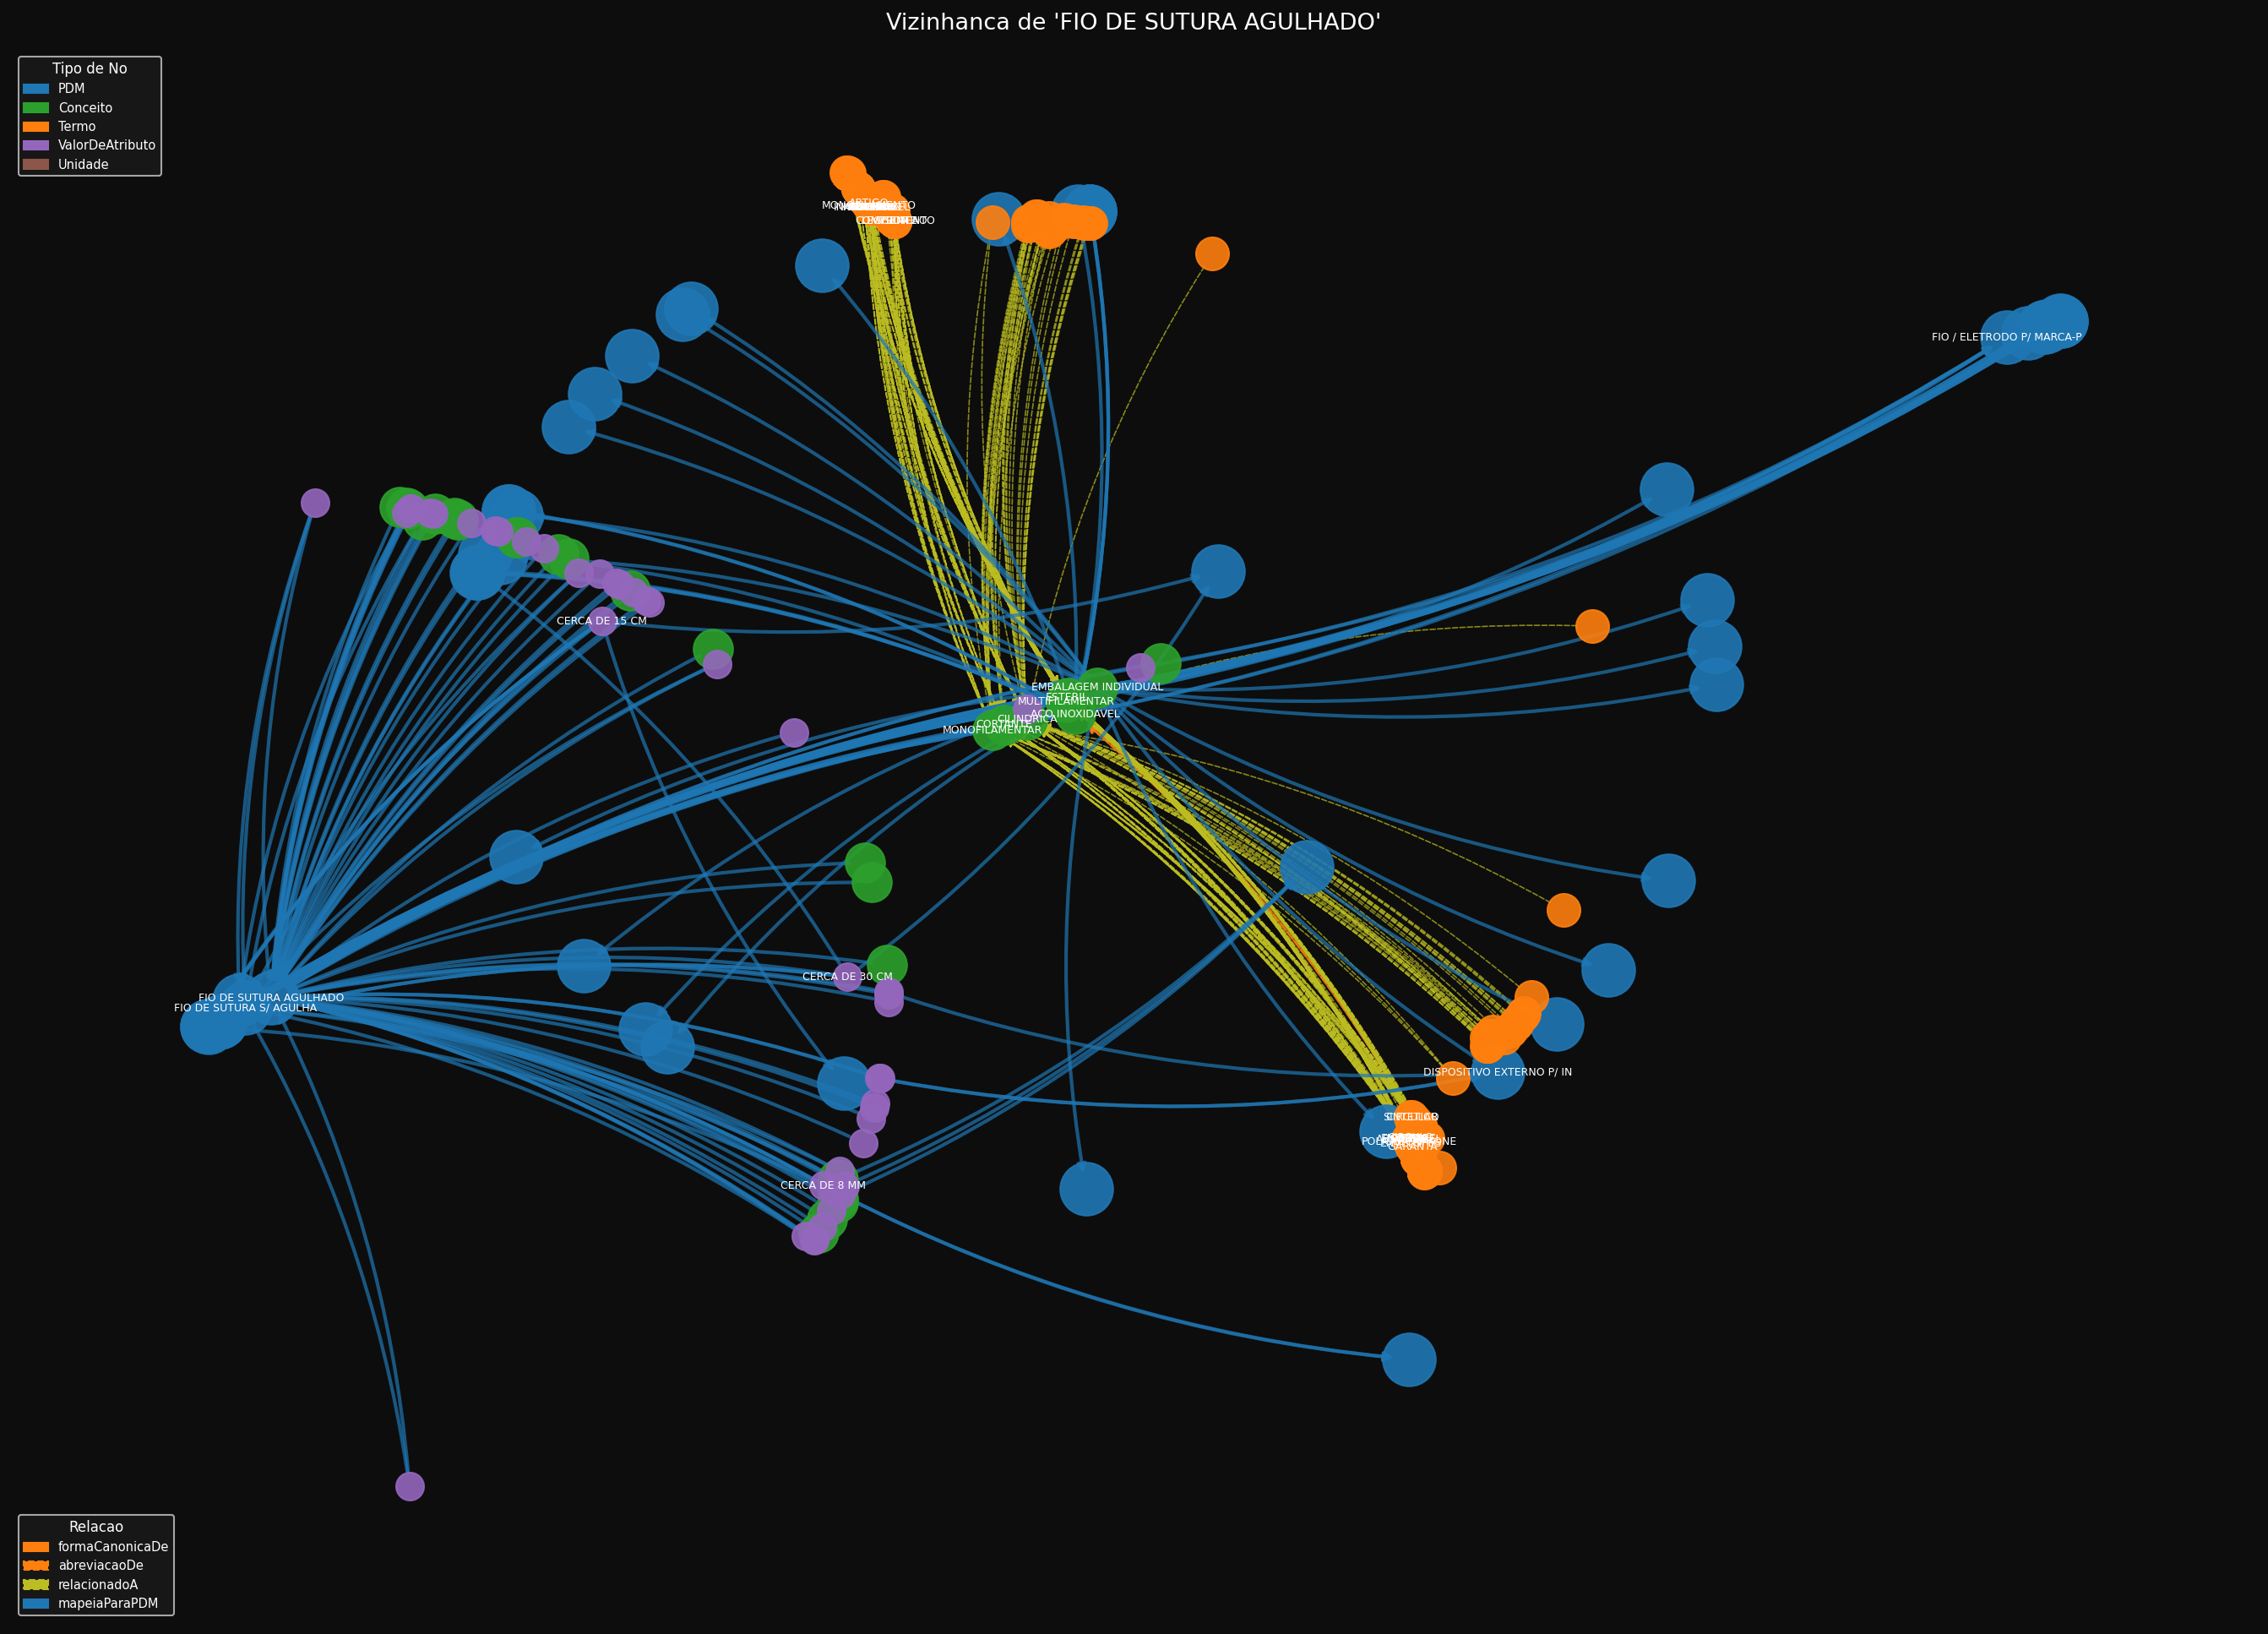

In [6]:
from IPython.display import Image, display

# Foca a visualização no PDM mais frequente do corpus
pdms = [(d.get("frequencia", 0), d["label"]) for _, d in G.nodes(data=True) if d["tipo"] == "PDM"]
pdm_foco = max(pdms)[1] if pdms else None
print("PDM em foco:", pdm_foco)

img = MMH_DIR / "vizinhanca_apresentacao.png"
visualizar_grafo(G, pdm_foco=pdm_foco, salvar_em=img,
                 titulo=f"Vizinhança semântica: {pdm_foco}")
display(Image(str(img)))

## 3. O módulo integrado: texto bruto → documento virtual expandido

Aqui o mapa **dirige** o pré-processamento. Para um item e-Fisco, o módulo:

1. limpa o texto (etapa 1);
2. **canoniza cada token** via grafo (`normalizar_termo`: abreviação/variante → forma canônica);
3. **expande por spreading activation** (`expandir_por_ativacao`: sinônimos, hiperônimos, relacionados);
4. **ancora ao PDM** do catálogo (`ancorar_pdm`);
5. emite o **documento virtual expandido** — a representação enriquecida que entra nos embeddings.

In [7]:
def preprocessar_com_grafo(item_efisco, G, limiar=0.1):
    """Módulo de pré-processamento guiado pelo mapa semântico."""
    base   = preprocessar_texto_efisco(item_efisco)          # 1. limpeza base
    tokens = tokenizar(base)
    canon  = [normalizar_termo(G, t) for t in tokens]         # 2. canonização via grafo
    ativados = expandir_por_ativacao(G, canon, limiar=limiar) # 3. spreading activation
    pdms = {c: ancorar_pdm(G, c) for c in canon if ancorar_pdm(G, c)}  # 4. ancoragem PDM
    termos = list(dict.fromkeys(canon + list(ativados.keys())))        # 5. doc virtual
    return {
        "base_limpa": base,
        "tokens_canonicos": canon,
        "termos_ativados": ativados,
        "ancoragem_pdm": pdms,
        "doc_virtual_expandido": " ".join(termos),
    }

r = preprocessar_com_grafo(exemplo, G)
print("ITEM e-Fisco:", exemplo[:140], "\n")
print("1. base limpa       :", r["base_limpa"])
print("2. tokens canônicos :", r["tokens_canonicos"])
print("3. termos ativados  :", {k: round(v, 2) for k, v in r["termos_ativados"].items()})
print("4. ancoragem PDM    :", r["ancoragem_pdm"])
print("\n>> DOCUMENTO VIRTUAL EXPANDIDO:")
print("   ", r["doc_virtual_expandido"])

ITEM e-Fisco: AGULHA DE MIELOGRAMA - ACO INOXIDAVEL, (ASPIRATIVA - ESTERNO E CRISTA ILIACA),COM LIMITADOR DE PROFUNDIDADE, SILICONIZADA,,USO UNICO, DESCAR 

1. base limpa       : AGULHA MIELOGRAMA ACO INOXIDAVEL ASPIRATIVA ESTERNO CRISTA ILIACA LIMITADOR PROFUNDIDADE SILICONIZADA USO UNICO DESCARTAVEL ESTERIL BIOPSIA OSSEA MIELOGRAMA 15G X 10 CM BISEL CORTANTE 45º CONEXAO LUER LOCK PAPEL GRAU CIRURGICO TRAVA SEGURANCA PLUG ANTI REFLUXO CABO ANATOMICO 31 LEI 8 078 90
2. tokens canônicos : ['AGULHAS', 'MIELOGRAMA', 'RADIOPACO', 'INOXIDAVEL', 'ASPIRATIVA', 'ESTERNO', 'CRISTA', 'ILIACA', 'LIMITADOR', 'PROFUNDIDADE', 'SILICONIZADA', 'USO', 'UNICO', 'DESCARTAVEL', 'ESTERILIDADE', 'BIOPSIA', 'INTRAOSSEA', 'MIELOGRAMA', '15G', 'X', '10', 'CM', 'BISEL', 'PERFUROCORTANTE', '45º', 'CONEXAO', 'LUER LOCK', 'LOCK', 'PAPEL', 'GRAU', 'CIRURGICO', 'TRAVA', 'SEGURANCA', 'PLUG', 'ANTIRREFLUXO', 'ANTIRREFLUXO', 'CABO', 'ANATOMICO', '31', 'LEI', '8', '078', '90']
3. termos ativados  : {'AGULHAS': 1.0, 'RAD

O **documento virtual expandido** é a entrega central: em vez de comparar strings cruas,
o casamento downstream compara representações onde abreviações já foram resolvidas, termos de
domínio foram enriquecidos por vizinhança semântica e o item já está ancorado a um PDM do CATMAT.

## 4. Métricas

Cobertura e OOV medem o alcance do mapa sobre o vocabulário; a completude mede a extração de
atributos; **recall@k / MRR** validam, downstream, que as representações produzidas recuperam o
CATMAT correto. Todos os números são lidos de `stats_pipeline.json`.

In [8]:
f1, f2, ret = stats["fase1"], stats["fase2"], stats["retrieval"]
pd.DataFrame([
    ["Mapa: nós",                  G.number_of_nodes()],
    ["Mapa: arestas",              G.number_of_edges()],
    ["Itens com PDM ancorado",     f1["n_com_pdm"]],
    ["Taxa OOV",                   f"{f1['taxa_oov']*100:.1f}%"],
    ["Completude de atributos",    f"{f2['escore_medio_completude']*100:.1f}%"],
    ["Validação — Recall@1",       f"{ret['recall_at_1']*100:.1f}%"],
    ["Validação — Recall@5",       f"{ret['recall_at_5']*100:.1f}%"],
    ["Validação — Recall@10",      f"{ret['recall_at_10']*100:.1f}%"],
    ["Validação — MRR",            f"{ret['mrr']:.3f}"],
], columns=["métrica", "valor"])

,métrica,valor
0,Mapa: nós,4198
1,Mapa: arestas,47084
2,Itens com PDM ancorado,1178
3,Taxa OOV,19.6%
4,Completude de atributos,94.4%
5,Validação — Recall@1,35.7%
6,Validação — Recall@5,73.7%
7,Validação — Recall@10,85.3%
8,Validação — MRR,0.525


## 5. Fechamento

**Entregue:** módulo de pré-processamento funcional guiado pelo mapa semântico — do texto e-Fisco
bruto ao documento virtual expandido, com cobertura, OOV e recall@k medidos.

**Pendências (não bloqueiam a apresentação):**
- avaliação com **negativos amostrados** (top-k CATMAT) para medir precisão fora do gold;
- fase opcional **[8b]** de explicabilidade via LLM — depende de `ANTHROPIC_API_KEY`.